In [11]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.random_search import RandomLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return RandomLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        generations=300,
        **params.converter_args)


Min: 0.0619 | Max: 0.1979 | Mean: 0.1249 | Std: 0.0448
Min: 0.0592 | Max: 0.1991 | Mean: 0.1346 | Std: 0.0484
Min: 0.0481 | Max: 0.1992 | Mean: 0.1331 | Std: 0.0500
Min: 0.0666 | Max: 0.1902 | Mean: 0.1311 | Std: 0.0470
Min: 0.0656 | Max: 0.1942 | Mean: 0.1353 | Std: 0.0466


C:\Users\wojte\AppData\Local\Temp\ipykernel_17856\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


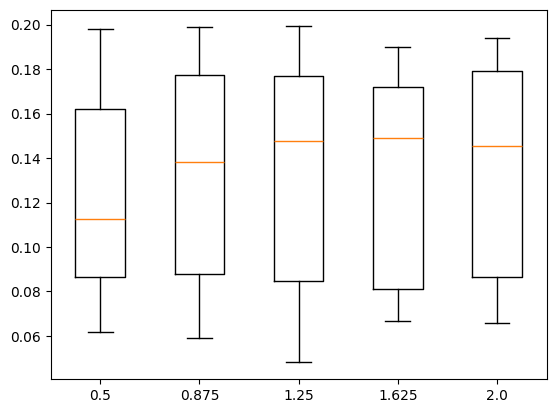

In [12]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [10]:
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = RandomLineSearch(symbols=SYMBOLS,
                             font=FONT,
                             generations=300)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, None, MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------
 | L-DDENNNELDD-/NyDL^`^N`L | DEE-^N/^/`^LLLNELNN/ND/E | 
 | /`D-LL/EDLLD`D`D-`-L`^Ey | NN`EDD/EDN`N/N^D/EyEDDD^ | 
 | D/-ED`EDNNDE/yDNEDyEL-/N | ^D``N^NNyLN-/DEDD/LEDy^D | 
 | NNDEDNNyELN/L-^ENNE`N/y/ | yDLDLNDy-/y/L^/EE`NLNyNE | 
 | y-NNyE`D/`-ENEEDNLLE--DN | N-NNyNNDDNLLy^^EDDNLyE-- | 
 | yNDEDDE`N/DENDDyD^DLEL`L | DyELN`EDDEDE`E^NNNLEEL`` | 
 | `NEN/DNDLND-NELN/DEND-E- | `-DNE/NEED/-E-^LLD^DDEED | 
 | yNLNE/^D`L^LLNNNDDNDyDLD | EDN/yENDEN-`NLL/Ny^^/yNN | 
 | /ED-`ENN^y/DNDED-N/DNNE^ | -/DDED^EDN-^LDL-E`//NN/y | 
---------------------------------------------------------
 | NNN`/`NL`-DELyLE/NEDENy- | -D``L--/L-` | 
 | ED/E^L^LyyDNDyL`--/L/`-` | DLNLDELDD`/ | 
 | -LN`LDDLN-/DNENNDLNDD`Dy | LENNDELD//N | 
 | `D^yDLDNLNN/DyDELLyyENyN | NN/NNE`yNEN | 
 | `-/-^/NN^NDDNNLNNN^L-ND^ | DyNEyNLENDD | 
 | NNNLEEN/y`DLDNLL^NEyDy`` | NNDN`ELN/DN | 
 | ^NE/NL``D`/--`yE`LELy-LN | NDE/^DL`NND | 
 | ^yL^yNyyDED/N`^-`LDy/NNN | DNDyN`DLNNL | 
 |